In [1]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: c:\Users\ADMIN\Documents\CV_Proj


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [3]:
import os

print(os.listdir(project_root))

['app', 'backend', 'Data', 'evaluation', 'frontend', 'inference', 'models', 'notebooks', 'patchcore', 'Results', 'temp', 'temp_000.png', 'temp_001.png', 'training']


In [4]:
import os 
print(os.getcwd())

c:\Users\ADMIN\Documents\CV_Proj\notebooks


In [5]:
print(os.listdir("../patchcore"))

['anomaly_scoring.py', 'coreset.py', 'feature_extractor.py', 'memory_bank.py', '_init_.py', '__pycache__']


In [6]:
from patchcore.feature_extractor import ResNetFeatureExtractor

In [7]:
from patchcore.feature_extractor import ResNetFeatureExtractor
import torch

extractor = ResNetFeatureExtractor().to(device)
extractor.eval()

dummy = torch.randn(1,3,256,256).to(device)

feat2, feat3 = extractor(dummy)

print("Layer2 feature shape:", feat2.shape)
print("Layer3 feature shape:", feat3.shape)

Layer2 feature shape: torch.Size([1, 256, 64, 64])
Layer3 feature shape: torch.Size([1, 512, 32, 32])


In [8]:
print("Grid size:", feat3.shape[-2], "x", feat3.shape[-1])
print("Total patches:", feat3.shape[-2] * feat3.shape[-1])

Grid size: 32 x 32
Total patches: 1024


In [74]:
def extract_patches(feature_map):
    """
    Converts feature map to patch embeddings
    
    Input: (B, C, H, W)
    Output: (H*W, C)
    """

    B, C, H, W = feature_map.shape

    # (B, H, W, C)
    patches = feature_map.permute(0, 2, 3, 1)

    # (H*W, C)
    patches = patches.reshape(-1, C)

    return patches

In [75]:
import torch.nn.functional as F

feat2, feat3 = extractor(dummy)

# downsample layer2 to layer3 resolution
feat2_resized = F.interpolate(
    feat2,
    size=feat3.shape[-2:],
    mode="bilinear",
    align_corners=False
)

patches2 = extract_patches(feat2_resized)
patches3 = extract_patches(feat3)

patches = torch.cat([patches2, patches3], dim=1)

print("Patch embedding shape:", patches.shape)

Patch embedding shape: torch.Size([1024, 768])


In [76]:
def extract_patches(feature_map):

    B, C, H, W = feature_map.shape

    patches = feature_map.permute(0, 2, 3, 1)

    patches = patches.reshape(-1, C)

    return patches

In [77]:
print("Total patches:", patches.shape[0])
print("Feature dimension:", patches.shape[1])

Total patches: 1024
Feature dimension: 768


In [78]:
from patchcore.memory_bank import MemoryBank

In [82]:
memory_bank = MemoryBank()

In [83]:
memory_bank.add(patches)

In [84]:
print(len(memory_bank.features))

1


In [85]:
bank = memory_bank.build()

print(bank.shape)

torch.Size([1024, 768])


In [86]:
from patchcore.anomaly_scoring import compute_anomaly_score

In [87]:
scores = compute_anomaly_score(patches, bank)

print(scores.shape)

torch.Size([1024])


In [88]:
print(scores[:10])

tensor([0.0000, 0.0000, 0.0048, 0.0028, 0.0000, 0.0000, 0.0000, 0.0000, 0.0028,
        0.0000], device='cuda:0', grad_fn=<SliceBackward0>)


In [89]:
image_score = scores.max()

print("Image anomaly score:", image_score.item())

Image anomaly score: 0.006176323629915714


In [90]:
print(scores.shape)
print(scores.max())

torch.Size([1024])
tensor(0.0062, device='cuda:0', grad_fn=<MaxBackward1>)


In [92]:
import math

def scores_to_map(scores):

    n_patches = scores.shape[0]

    grid_size = int(math.sqrt(n_patches))

    anomaly_map = scores.reshape(grid_size, grid_size)

    return anomaly_map

In [93]:
patch_map = scores_to_map(scores)

print(patch_map.shape)

torch.Size([32, 32])


In [94]:
print(scores.shape)

torch.Size([1024])


In [95]:
patch_map= scores.reshape(32,32)

In [96]:
print("feat2 shape:", feat2.shape)
print("feat3 shape:", feat3.shape)
print("patches shape:", patches.shape)
print("scores shape:", scores.shape)

feat2 shape: torch.Size([1, 256, 64, 64])
feat3 shape: torch.Size([1, 512, 32, 32])
patches shape: torch.Size([1024, 768])
scores shape: torch.Size([1024])


In [97]:
import math

num_patches = scores.shape[0]

grid_size = int(math.sqrt(num_patches))

patch_map = scores.reshape(grid_size, grid_size)

In [98]:
patch_map = patch_map.detach().cpu().numpy()

In [99]:
import cv2

heatmap = cv2.resize(patch_map, (256,256))

print(heatmap.shape)

(256, 256)


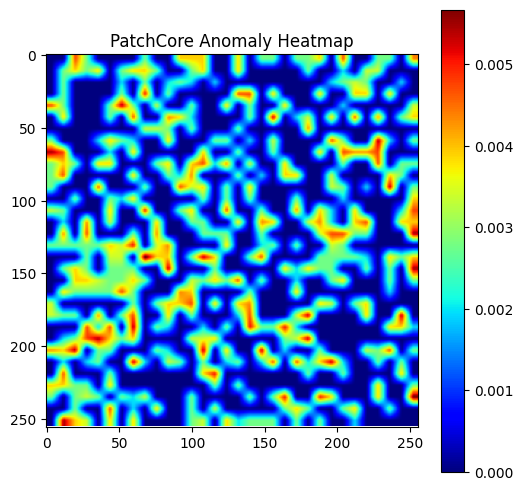

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.imshow(heatmap, cmap="jet")

plt.title("PatchCore Anomaly Heatmap")

plt.colorbar()

plt.show()

In [101]:
def overlay_heatmap(image, heatmap):

    heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
    heatmap_norm = 1 - heatmap_norm

    heatmap_color = cv2.applyColorMap(
        (heatmap_norm*255).astype("uint8"),
        cv2.COLORMAP_JET
    )

    image_np = image.permute(1,2,0).cpu().numpy()

    image_np = (image_np*255).astype("uint8")

    overlay = cv2.addWeighted(image_np,0.6,heatmap_color,0.4,0)

    return overlay

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

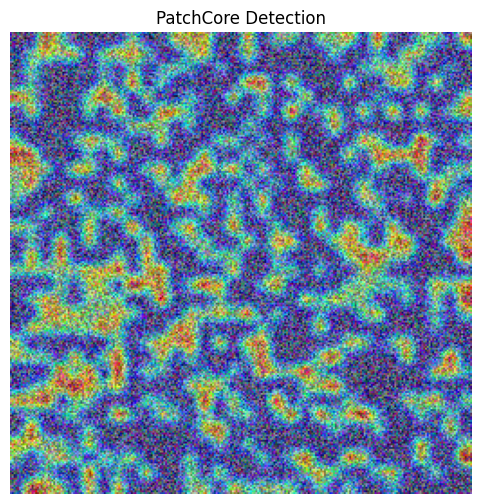

In [102]:
overlay = overlay_heatmap(dummy[0], heatmap)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("PatchCore Detection")
plt.axis("off")

In [103]:
import os

train_path = "../Data/mvtec/bottle/train/good"

print("Number of training images:", len(os.listdir(train_path)))

Number of training images: 209


In [104]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [105]:
from patchcore.memory_bank import MemoryBank

memory_bank = MemoryBank()

In [106]:
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm

image_files = os.listdir(train_path)

for img_name in tqdm(image_files):

    img_path = os.path.join(train_path, img_name)

    image = Image.open(img_path).convert("RGB")

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        feat2, feat3 = extractor(image)

        # align spatial sizes
        feat2_resized = F.interpolate(
            feat2,
            size=feat3.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

    patches2 = extract_patches(feat2_resized)
    patches3 = extract_patches(feat3)

    patches = torch.cat([patches2, patches3], dim=1)

    memory_bank.add(patches)

100%|██████████| 209/209 [00:05<00:00, 36.53it/s]


In [107]:
bank = memory_bank.build()
print(bank.shape)

torch.Size([214016, 768])


In [108]:
test_path = "../Data/mvtec/bottle/test"

import os

test_categories = os.listdir(test_path)

print(test_categories)

['broken_large', 'broken_small', 'contamination', 'good']


In [109]:
defect_folder = os.path.join(test_path, "broken_large")
test_images = os.listdir(defect_folder)
print(test_images[:5])

['000.png', '001.png', '002.png', '003.png', '004.png']


(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

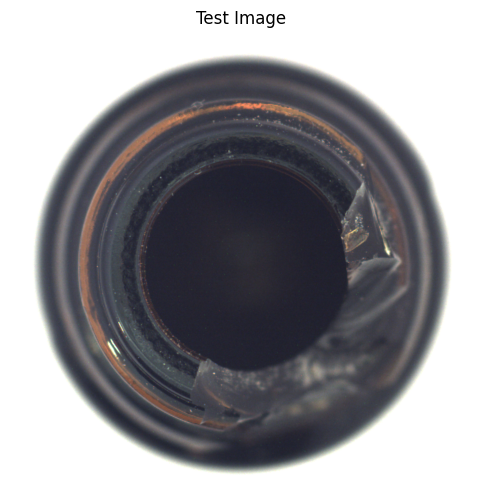

In [110]:
img_path = os.path.join(defect_folder, test_images[0])

image = Image.open(img_path).convert("RGB")

import numpy as np

plt.figure(figsize=(6,6))

plt.imshow(np.array(image))

plt.title("Test Image")

plt.axis("off")

In [111]:
print(image.mode)
print(image.size)

RGB
(900, 900)


In [112]:
img_tensor = transform(image).unsqueeze(0).to(device)

In [113]:
import torch.nn.functional as F

with torch.no_grad():
    feat2, feat3 = extractor(img_tensor)

    # align spatial size
    feat2_resized = F.interpolate(
        feat2,
        size=feat3.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

patches2 = extract_patches(feat2_resized)
patches3 = extract_patches(feat3)

patches = torch.cat([patches2, patches3], dim=1)

print("patches shape:", patches.shape)

patches shape: torch.Size([1024, 768])


In [114]:
scores  = compute_anomaly_score(patches, bank)

In [115]:
print(scores.shape)

torch.Size([1024])


In [116]:
import math

# compute grid size dynamically
grid_size = int(math.sqrt(scores.shape[0]))

patch_map = scores.reshape(grid_size, grid_size).detach().cpu().numpy()

# normalize
patch_map = (patch_map - patch_map.min()) / (patch_map.max() - patch_map.min())

# invert so anomalies = red



In [117]:
import cv2

patch_map = cv2.GaussianBlur(patch_map, (3,3), 0)

In [118]:
heatmap = cv2.resize(patch_map, (256,256))

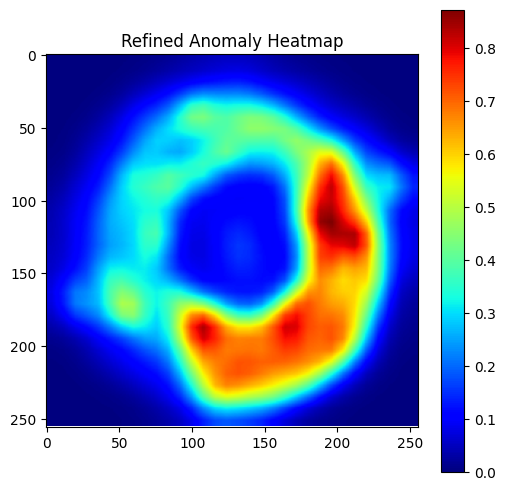

In [119]:
plt.figure(figsize=(6,6))

plt.imshow(heatmap, cmap="jet")

plt.title("Refined Anomaly Heatmap")

plt.colorbar()

plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

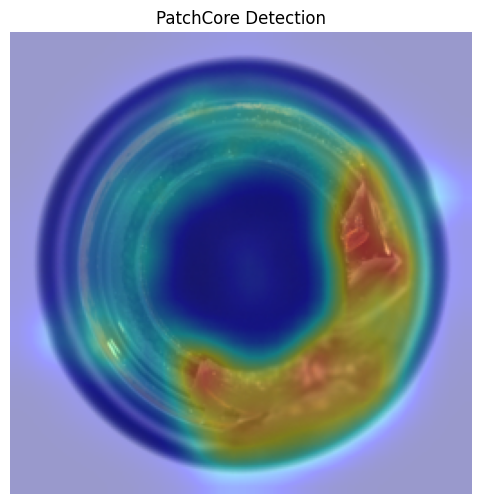

In [120]:
heatmap_color = cv2.applyColorMap(
    (heatmap*255).astype("uint8"),
    cv2.COLORMAP_JET
)

image_np = img_tensor[0].permute(1,2,0).cpu().numpy()
image_np = (image_np*255).astype("uint8")

image_np = cv2.cvtColor(image_np, cv2.COLOR_RGB2BGR)

overlay = cv2.addWeighted(image_np,0.6,heatmap_color,0.4,0)

overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.title("PatchCore Detection")
plt.axis("off")

In [121]:
print(scores.max(), scores.min())

tensor(3.4697, device='cuda:0') tensor(0., device='cuda:0')


In [122]:
print(bank.shape)

torch.Size([214016, 768])


In [123]:
print(scores.max(), scores.min())

tensor(3.4697, device='cuda:0') tensor(0., device='cuda:0')


In [124]:
bank.element_size() * bank.nelement() / (1024 * 102)

6294.588235294118

In [125]:
from patchcore.coreset import coreset_sampling

In [126]:
coreset_bank = coreset_sampling(bank, sampling_ratio=0.1)

print("Original memory bank:", bank.shape)
print("Coreset memory bank:", coreset_bank.shape)

Original memory bank: torch.Size([214016, 768])
Coreset memory bank: torch.Size([21401, 768])


In [127]:
scores = compute_anomaly_score(patches, coreset_bank)

In [128]:
print(coreset_bank.shape)

torch.Size([21401, 768])


In [129]:
print(patches.shape)

torch.Size([1024, 768])


In [130]:
assert grid_size * grid_size == num_patches, "Patches do not form a square grid"

In [131]:
import sys
sys.path.append(r"C:\Users\ADMIN\Documents\CV_Proj")

from backend.inference import run_patchcore

In [132]:
import glob
import os
import torch

train_path = r"C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\train\good"
image_paths = glob.glob(os.path.join(train_path, "*.png"))

memory_bank = []

print(f"Total training images: {len(image_paths)}")

for img_path in image_paths:
    
    image = Image.open(img_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        feat2, feat3 = extractor(img_tensor)
        
        feat2_resized = F.interpolate(
            feat2,
            size=feat3.shape[-2:],
            mode="bilinear",
            align_corners=False
        )
        
        patches2 = extract_patches(feat2_resized)
        patches3 = extract_patches(feat3)
        
        patches = torch.cat([patches2, patches3], dim=1)
    
    memory_bank.append(patches.cpu())

# combine all
memory_bank = torch.cat(memory_bank, dim=0)

print("Memory bank shape:", memory_bank.shape)

Total training images: 209
Memory bank shape: torch.Size([214016, 768])


In [133]:
os.makedirs("models", exist_ok=True)

torch.save(memory_bank, "models/bottle_memory.pt")

print("✅ Memory bank saved!")

✅ Memory bank saved!


In [134]:
import glob
import os

# path to GOOD images
good_path = r"C:\Users\ADMIN\Documents\CV_Proj\Data\mvtec\bottle\test\good"

image_paths = glob.glob(os.path.join(good_path, "*.png"))

normal_scores = []

print(f"Total good images: {len(image_paths)}")

# loop through images
for img_path in image_paths[:30]:  # start with 30 images (fast)
    
    heatmap, score = run_patchcore("bottle", img_path)
    
    normal_scores.append(score)

# print results
print("\nNormal Score Stats:")
print("Min:", min(normal_scores))
print("Max:", max(normal_scores))
print("Avg:", sum(normal_scores)/len(normal_scores))

Total good images: 20

Normal Score Stats:
Min: 2.8645212650299072
Max: 2.8645572662353516
Avg: 2.864540719985962


In [135]:
print(memory_bank.shape)

torch.Size([214016, 768])


In [136]:
print(memory_bank[:5])

tensor([[0.0541, 0.1857, 0.1226,  ..., 0.0820, 0.0000, 0.2071],
        [0.0281, 0.1782, 0.2301,  ..., 0.1443, 0.0000, 0.1163],
        [0.0280, 0.1781, 0.2530,  ..., 0.1371, 0.0000, 0.0779],
        [0.0280, 0.1781, 0.2542,  ..., 0.1335, 0.0000, 0.0676],
        [0.0280, 0.1781, 0.2542,  ..., 0.1322, 0.0000, 0.0702]])


In [140]:
def coreset_sampling(patches, sampling_ratio=0.01, min_samples=500):
    
    n_patches = patches.shape[0]
    n_select = max(int(n_patches * sampling_ratio), min_samples)

    # random start
    selected_indices = [torch.randint(0, n_patches, (1,)).item()]

    distances = torch.cdist(patches, patches[selected_indices])

    for _ in range(n_select - 1):
        farthest_idx = torch.argmax(distances.min(dim=1)[0]).item()
        selected_indices.append(farthest_idx)

        new_dist = torch.cdist(patches, patches[[farthest_idx]])
        distances = torch.minimum(distances, new_dist)

    return patches[selected_indices]

In [143]:
memory_bank = coreset_sampling(patches, sampling_ratio=0.01, min_samples=500)

torch.save(memory_bank, "models/bottle_memory.pth")

In [144]:
print(memory_bank.shape)

torch.Size([500, 768])
